# Tests — simulation methods (LMC model)

Justification for the simulator used in the pipeline [spatial_analysis_article.ipynb](spatial_analysis_article.ipynb). The **direct LMC** model (the `\new{}` model in [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex)) can be simulated two ways, differing only in how the three latent Gaussian fields $W^c, W^{(0)}, W^{(1)}$ are drawn:

- **Cholesky** — `simulate_cholesky`: factor each $\Sigma_k=\mathbf L_k\mathbf L_k^\top$ once, then $\mathbf W^k=\mathbf L_k\mathbf V^k$, with a burn-in. **This is what the pipeline uses.**
- **per-step SVD** — `simulate_history` / `step_spatial_markov`: `rng.multivariate_normal` (SVD factorisation) for each field, refactored every step, no burn-in.

Both assemble $Z^{(r)}=(-1)^r\sqrt{\lambda}\,W^c+\sqrt{1-\lambda}\,W^{(r)}$ and select $Z=Z^{(R)}$ (Eq. lmc_fields_direct / z_selection_direct). Drawing $\mathbf W=\mathbf A\mathbf V$ with $\mathbf V\sim\mathcal N(0,I)$ gives $\operatorname{Cov}=\mathbf A\mathbf A^\top$, so **any** factor with $\mathbf A\mathbf A^\top=\Sigma_k$ samples the same law — Cholesky and SVD are two such factors. We confirm matching marginals and $\hat\theta$, then look at the burn-in. The single-field simulators are archived under [archive_old_single_latent_field/](archive_old_single_latent_field/).

## Setup

Build `dict_model_params` exactly as in the pipeline notebook (model-agnostic, shared with the old model).

In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    simulate_cholesky,
    simulate_history,
    mle_theta_pairwise,
)

In [2]:
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
    df_fit_dry, df_fit_wet, stations_used, countries=["PT", "ES"], season="spring",
)
dict_model_params = build_dict_model_params(
    df_fit_dry_sub, df_fit_wet_sub, spells, season="spring",
)
print(f"Built model parameters for {len(dict_model_params)} stations")

  0%|          | 0/35 [00:00<?, ?it/s]

 94%|█████████▍| 33/35 [00:00<00:00, 322.96it/s]

100%|██████████| 35/35 [00:00<00:00, 318.61it/s]

Built model parameters for 35 stations


## Cholesky vs per-step SVD — same law

Simulate one long history at a fixed $\theta$ with each method and compare per-station wet-day frequencies and the recovered $\hat\theta$. They should agree up to Monte-Carlo noise.

max |wet_chol - wet_svd| = 0.0560
theta_true = (0.6, 0.3, 0.15, 0.45)
  Cholesky  simulator -> theta_hat = (0.739, 0.188, 0.233, 1.565)
  SVD       simulator -> theta_hat = (0.500, 0.371, 0.142, 0.274)


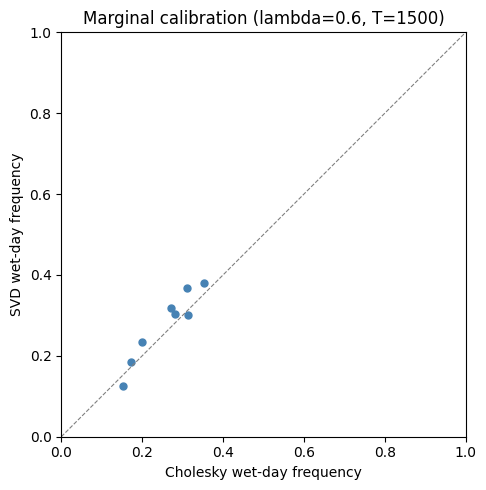

In [3]:
THETA = (0.6, 0.30, 0.15, 0.45)   # (lambda, sigma_wc, sigma_w0, sigma_w1)
names = sorted(dict_model_params)[:8]
params = {c: dict_model_params[c] for c in names}
T = 1500

# Cholesky simulator (the pipeline's method), with burn-in.
h_chol = simulate_cholesky(THETA, params, n_steps=T, n_burn=500, station_names=names, seed=0)

# per-step SVD simulator (numpy multivariate_normal), no burn-in.
R0 = np.zeros(len(names), dtype=int)
D0 = np.ones(len(names), dtype=int)
h_svd = simulate_history(n_steps=T, R0=R0, D0=D0, theta=THETA,
                         params_by_station=params, station_names=names, seed=0)

wet_chol = h_chol["R"][1:].mean(axis=0)
wet_svd = h_svd["R"][1:].mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.scatter(wet_chol, wet_svd, s=25, color="steelblue")
ax.set_xlabel("Cholesky wet-day frequency"); ax.set_ylabel("SVD wet-day frequency")
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"Marginal calibration (lambda={THETA[0]}, T={T})")
plt.tight_layout()

r_chol = mle_theta_pairwise(h_chol, params, vectorized=True)["theta_hat"]
r_svd = mle_theta_pairwise(h_svd, params, vectorized=True)["theta_hat"]
fmt = lambda t: f"({t['lam']:.3f}, {t['sigma_wc']:.3f}, {t['sigma_w0']:.3f}, {t['sigma_w1']:.3f})"
print(f"max |wet_chol - wet_svd| = {np.abs(wet_chol - wet_svd).max():.4f}")
print(f"theta_true = {THETA}")
print(f"  Cholesky  simulator -> theta_hat = {fmt(r_chol)}")
print(f"  SVD       simulator -> theta_hat = {fmt(r_svd)}")

## Effect of the burn-in

Start `simulate_cholesky` from the deterministic all-dry state with `n_burn=0` and track the cross-station wet fraction day by day. If a burn-in is needed, the first days sit away from the stationary level and drift toward it; the running mean shows how many days that takes and motivates the default `n_burn`.

wet fraction: days 1-50 = 0.307, days 500+ = 0.273


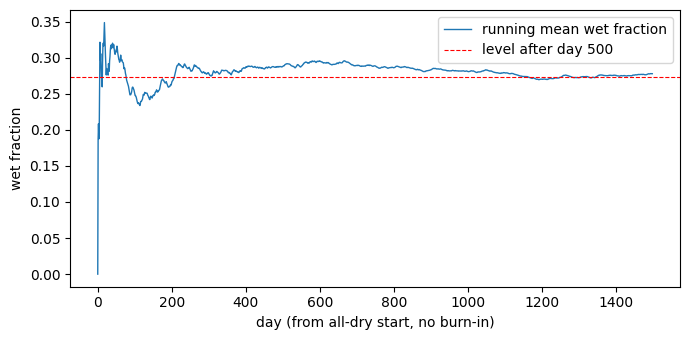

In [4]:
h0 = simulate_cholesky(THETA, params, n_steps=1500, n_burn=0, station_names=names, seed=1)

wet_frac_t = h0["R"][1:].mean(axis=1)                 # mean over stations, per day
run_mean = np.cumsum(wet_frac_t) / np.arange(1, len(wet_frac_t) + 1)
stationary = h0["R"][500:].mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(run_mean, lw=1, label="running mean wet fraction")
ax.axhline(stationary, color="red", ls="--", lw=0.8, label="level after day 500")
ax.set_xlabel("day (from all-dry start, no burn-in)"); ax.set_ylabel("wet fraction")
ax.legend(); plt.tight_layout()

print(f"wet fraction: days 1-50 = {wet_frac_t[:50].mean():.3f}, days 500+ = {stationary:.3f}")